In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp

sys.path.insert(0, "/data/user/akatil/electron_neutrino/for_real/analysis_chain/")

from analysis_helpers import get_mean_upgrade_positions

In [2]:
#getting the geometry frame. We want this to calculate the mean of upgrade om x and y positions
gcd_infile = dataio.I3File('/home/akatil/GeoCalibDetectorStatus_ICUpgrade.v58.mixed.V1.i3.bz2')

f_geo = gcd_infile
geo_frame = f_geo.pop_frame(icetray.I3Frame.Geometry)
geo = geo_frame['I3Geometry']

ux, uy, uz = get_mean_upgrade_positions(geo)

fCC = h5py.File('../../delete_merger_CC.h5', 'r')
fNC = h5py.File('../../delete_merger.h5', 'r')

In [3]:
fCC['PrimaryEnergy'][0:100099]

array([(121429,    0, 0, 0, 1, 10.25925696),
       (121429,  147, 0, 0, 1, 12.08053137),
       (121429,  177, 0, 0, 1, 25.41958038), ...,
       (121429, 2873, 0, 0, 1,  2.01929454),
       (121429, 2911, 0, 0, 1,  5.62545904),
       (121429, 2928, 0, 0, 1,  2.64104512)],
      dtype={'names': ['Run', 'Event', 'SubEvent', 'SubEventStream', 'exists', 'value'], 'formats': ['<u4', '<u4', '<u4', '<i4', 'u1', '<f8'], 'offsets': [0, 4, 8, 12, 16, 24], 'itemsize': 32})

In [4]:
emin, emax = 0, 100

imin, imax = 0, 1

def get_filtered_data(f, interaction_type):
    #### First make event level cuts ######
    # cuts on energy
    # cuts on inelasticity, only for CC
    # cuts on vertex
    
    event_counter = f['EventCounter']['value'][0:100099]
    om_counter = f['OMMapTrue']['om_counter'][0:100099]
    
    energy = f['PrimaryEnergy']['value'][0:100099]
    inelasticity = f['Inelasticity']['value'][0:100099]
    
    trueX = f['TrueX']['value'][0:100099]
    trueY = f['TrueY']['value'][0:100099]
    trueZ = f['TrueZ']['value'][0:100099]
    
    energy_boolean = (energy >= emin) & (energy <= emax)
    inelasticity_boolean = (inelasticity >= imin) & (inelasticity <= imax)
    vertex_boolean = (trueZ <= uz+150)&(trueZ >= uz-150)&(trueX <= ux+50)&(trueX >= ux-50)&(trueY <= uy+40)&(trueY >= uy-40)

    if interaction_type == 0:
        event_boolean = energy_boolean & inelasticity_boolean & vertex_boolean
    if interaction_type == 1:
        event_boolean = energy_boolean & vertex_boolean
    
    select_event_counter = event_counter[event_boolean]
    
    # Apply the cuts
    filtered_data = {}
    
    # Loop through all keys (datasets) and apply the cut
    for key in f.keys():
        data = f[key][0:100099]
        if key == 'OMMapReco' or key == 'OMMapTrue':
            om_event_condition = np.where(np.isin(om_counter, select_event_counter))[0]
            filtered_data[key] = data[om_event_condition]
        else:
            filtered_data[key] = data[event_boolean]  # This applies the condition to each dataset

    return filtered_data

In [5]:
filtered_dataCC = get_filtered_data(fCC, 0)

In [6]:
filtered_dataNC = get_filtered_data(fNC, 1)

In [7]:
filtered_dataCC.keys()

dict_keys(['Azimuth', 'Beta1', 'Beta1Reco', 'Beta2', 'Beta2Reco', 'Beta3', 'Beta3Reco', 'Beta4', 'Beta4Reco', 'Beta5', 'Beta5Reco', 'CogX', 'CogY', 'CogZ', 'EventCounter', 'Inelasticity', 'OMMapReco', 'OMMapTrue', 'PrimaryEnergy', 'RecoDirX', 'RecoDirY', 'RecoDirZ', 'RecoEnergy', 'RecoVertexTime', 'RecoX', 'RecoY', 'RecoZ', 'SecondaryEnergy', 'TotalCharge', 'TotalmDOMCharge', 'TrueTime', 'TrueX', 'TrueY', 'TrueZ', 'Zenith', 'filename'])

In [8]:
def reco_vs_true(trueCC, recoCC, xlabelCC, ylabelCC, 
                 trueNC, recoNC, xlabelNC, ylabelNC):
    
    fig, axs = plt.subplots(1, 2)
    fig.set_figheight(8)
    fig.set_figwidth(20)
    
    a0 = axs[0].hist2d(trueCC, recoCC, cmap='jet', norm=LogNorm(), density=False, bins=100)
    fig.colorbar(a0[3], ax=axs[0])
    axs[0].set_xlabel(xlabelCC, fontsize = 18)
    axs[0].set_ylabel(ylabelCC, fontsize = 18)
    axs[0].set_title('CC - Energy {} - {} GeV'.format(emin, emax))
    
    lims = [
        np.min([axs[0].get_xlim(), axs[0].get_ylim()]),
        np.max([axs[0].get_xlim(), axs[0].get_ylim()]),
    ]
    
    axs[0].plot(lims, lims, 'k-', lw=3)
    
    
    a1 = axs[1].hist2d(trueNC, recoNC, cmap='jet', norm=LogNorm(), density=False, bins=100)
    fig.colorbar(a1[3], ax=axs[1])
    axs[1].set_xlabel(xlabelNC, fontsize = 18)
    axs[1].set_ylabel(ylabelNC, fontsize = 18)
    axs[1].set_title('NC - Energy {} - {} GeV'.format(emin, emax))
    
    lims = [
        np.min([axs[1].get_xlim(), axs[1].get_ylim()]),
        np.max([axs[1].get_xlim(), axs[1].get_ylim()]),
    ]
    
    axs[1].plot(lims, lims, 'k-', lw=3)
    
    plt.show()

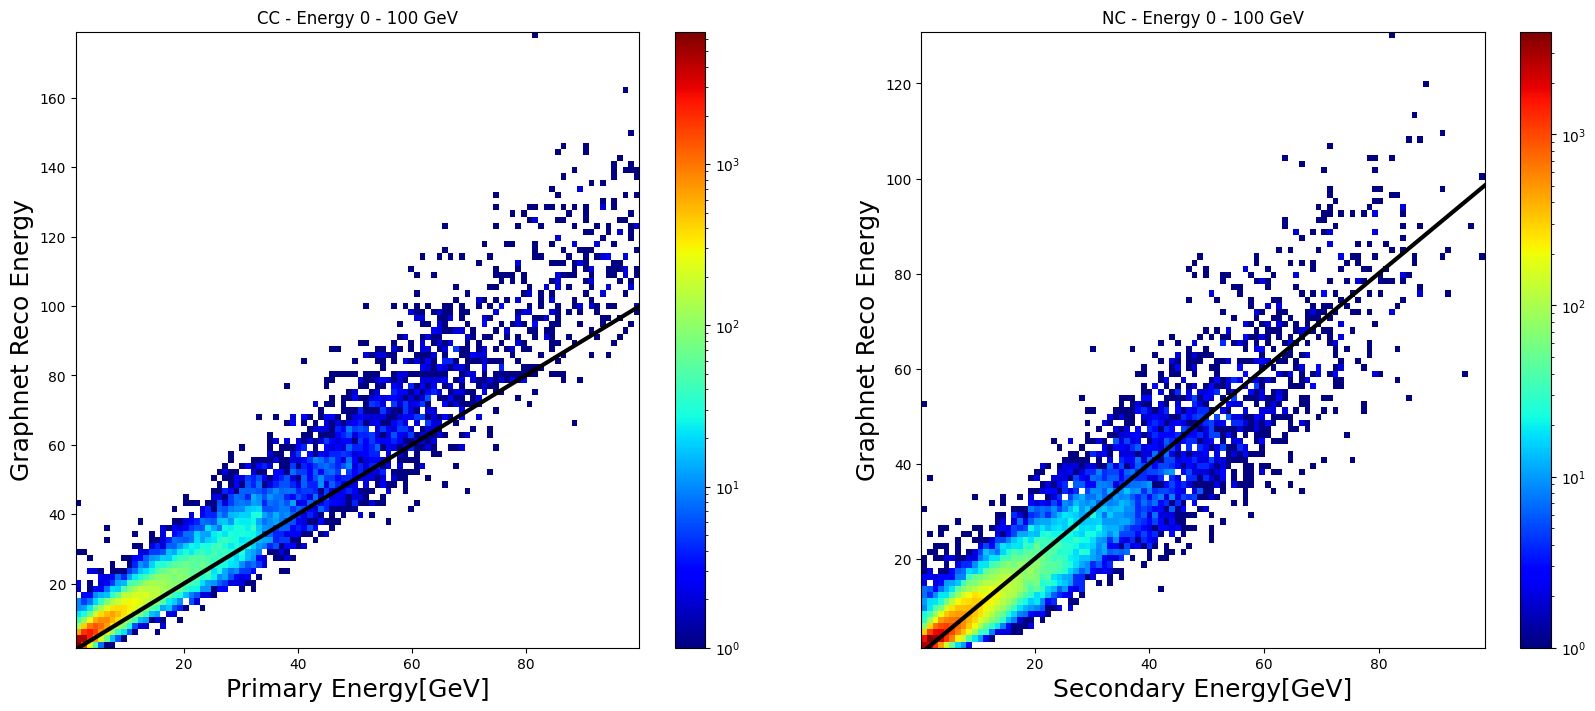

In [9]:
#reco vs true energy plot

reco_vs_true(filtered_dataCC['PrimaryEnergy']['value'], filtered_dataCC['RecoEnergy']['value'], 'Primary Energy[GeV]', 'Graphnet Reco Energy',
            filtered_dataNC['SecondaryEnergy']['value'], filtered_dataNC['RecoEnergy']['value'], 'Secondary Energy[GeV]', 'Graphnet Reco Energy')

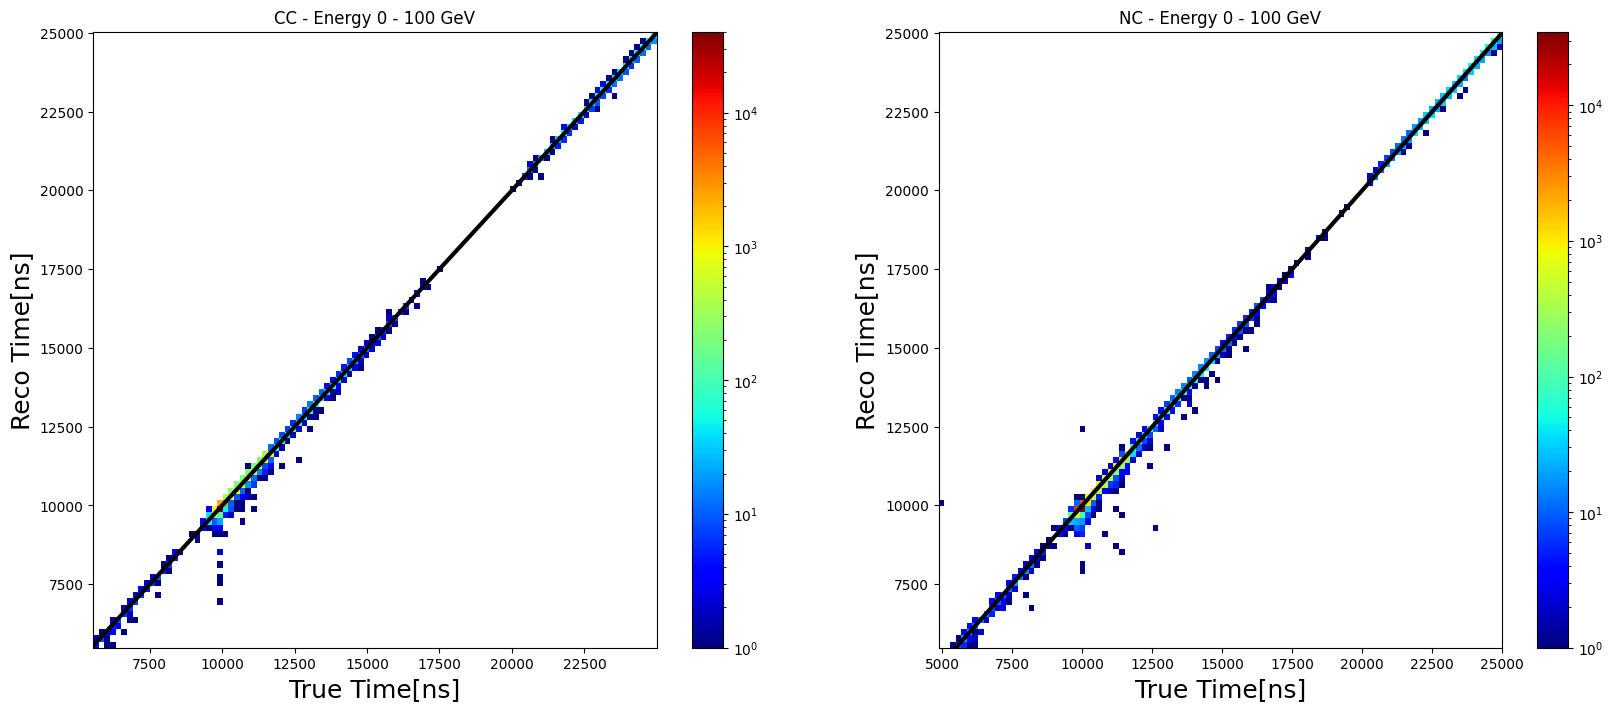

In [10]:
#reco vs true time

reco_vs_true(filtered_dataCC['TrueTime']['value'], filtered_dataCC['RecoVertexTime']['value'], 'True Time[ns]', 'Reco Time[ns]',
            filtered_dataNC['TrueTime']['value'], filtered_dataNC['RecoVertexTime']['value'], 'True Time[ns]', 'Reco Time[ns]',)

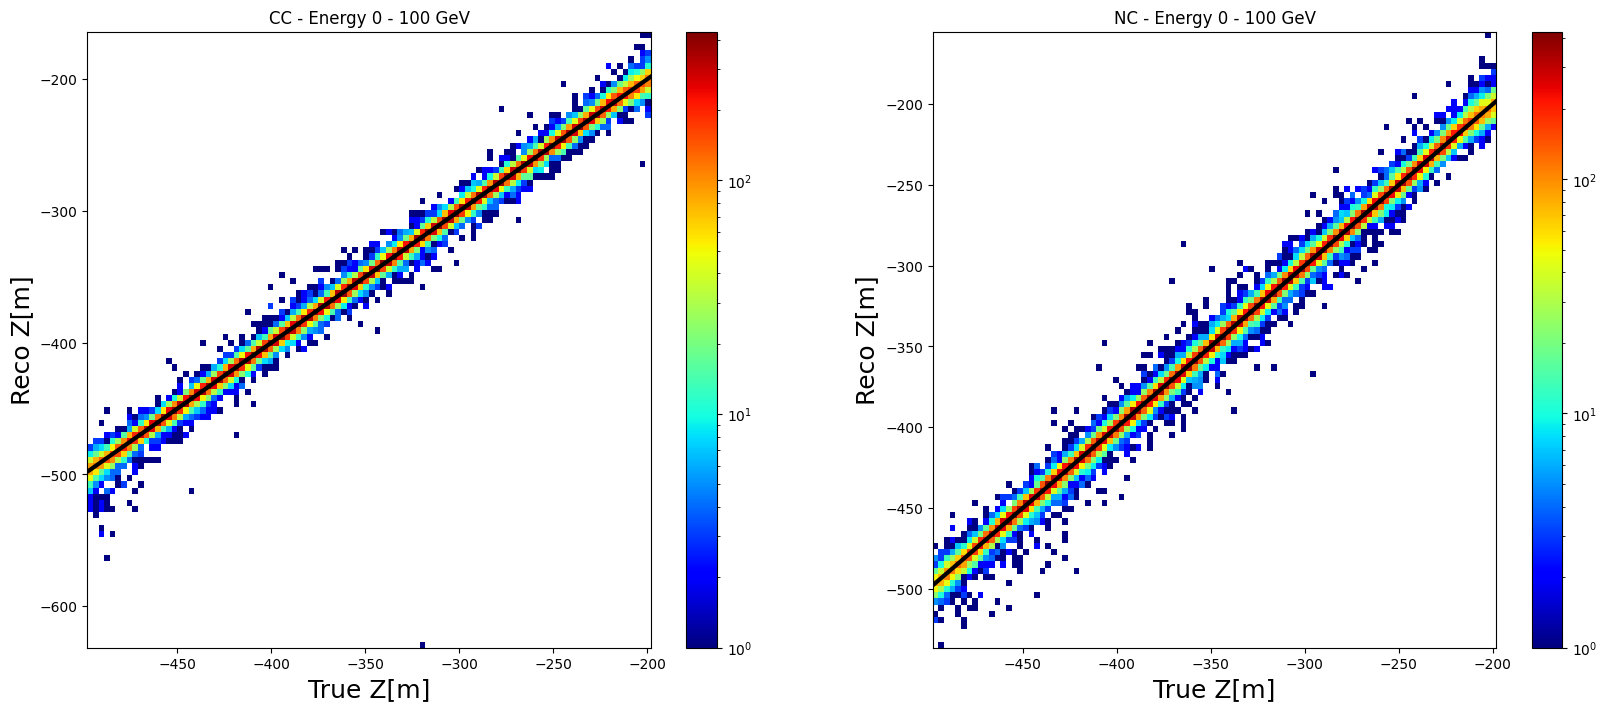

In [11]:
#reco vs true z 

reco_vs_true(filtered_dataCC['TrueZ']['value'], filtered_dataCC['RecoZ']['value'], 'True Z[m]', 'Reco Z[m]',
            filtered_dataNC['TrueZ']['value'], filtered_dataNC['RecoZ']['value'], 'True Z[m]', 'Reco Z[m]',)

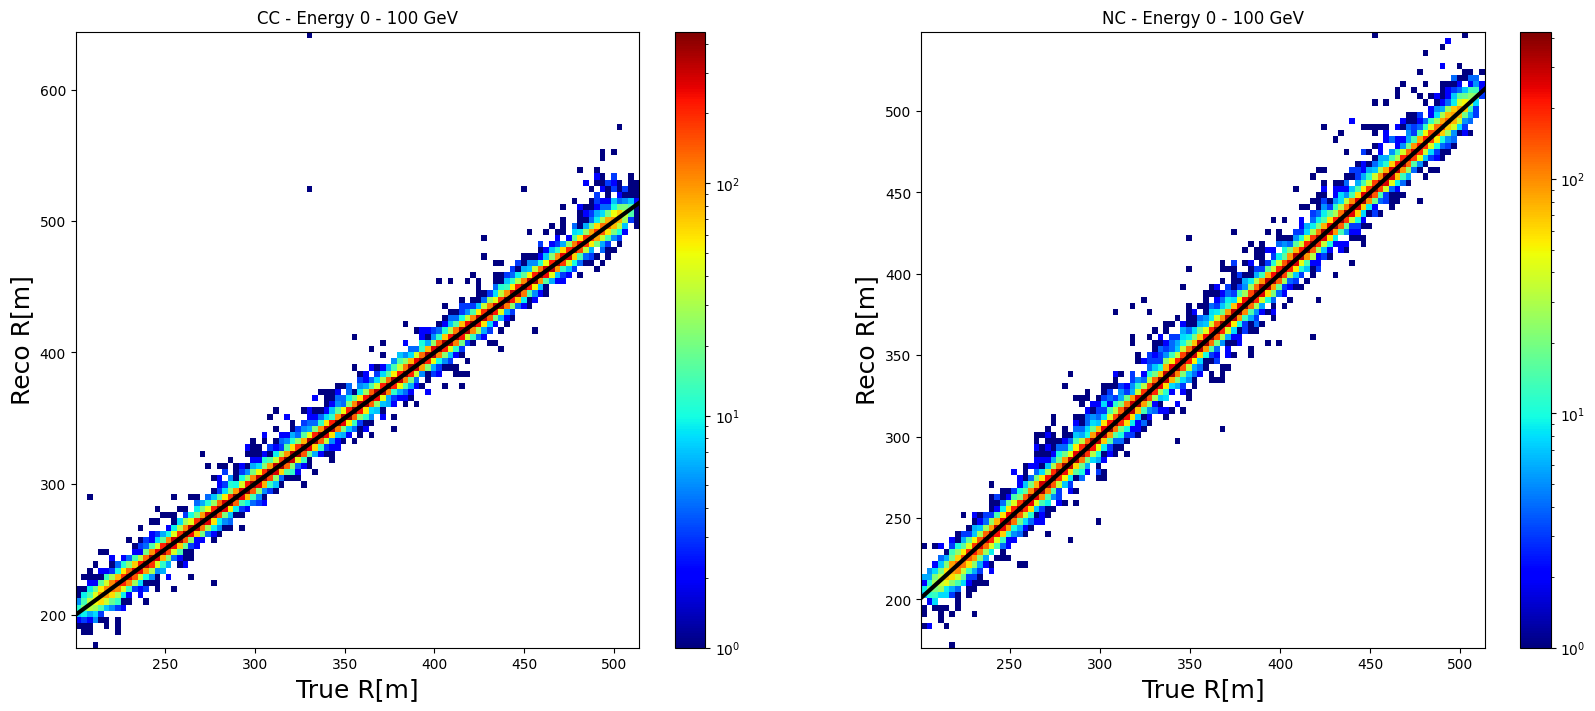

In [12]:
# reco vs true R

true_RCC = np.sqrt(filtered_dataCC['TrueX']['value']**2+filtered_dataCC['TrueY']['value']**2+filtered_dataCC['TrueZ']['value']**2)
reco_RCC = np.sqrt(filtered_dataCC['RecoX']['value']**2+filtered_dataCC['RecoY']['value']**2+filtered_dataCC['RecoZ']['value']**2)

true_RNC = np.sqrt(filtered_dataNC['TrueX']['value']**2+filtered_dataNC['TrueY']['value']**2+filtered_dataNC['TrueZ']['value']**2)
reco_RNC = np.sqrt(filtered_dataNC['RecoX']['value']**2+filtered_dataNC['RecoY']['value']**2+filtered_dataNC['RecoZ']['value']**2)

reco_vs_true(true_RCC, reco_RCC, 'True R[m]', 'Reco R[m]',
            true_RNC, reco_RNC, 'True R[m]', 'Reco R[m]',)

In [13]:
filtered_dataCC.keys()

dict_keys(['Azimuth', 'Beta1', 'Beta1Reco', 'Beta2', 'Beta2Reco', 'Beta3', 'Beta3Reco', 'Beta4', 'Beta4Reco', 'Beta5', 'Beta5Reco', 'CogX', 'CogY', 'CogZ', 'EventCounter', 'Inelasticity', 'OMMapReco', 'OMMapTrue', 'PrimaryEnergy', 'RecoDirX', 'RecoDirY', 'RecoDirZ', 'RecoEnergy', 'RecoVertexTime', 'RecoX', 'RecoY', 'RecoZ', 'SecondaryEnergy', 'TotalCharge', 'TotalmDOMCharge', 'TrueTime', 'TrueX', 'TrueY', 'TrueZ', 'Zenith', 'filename'])

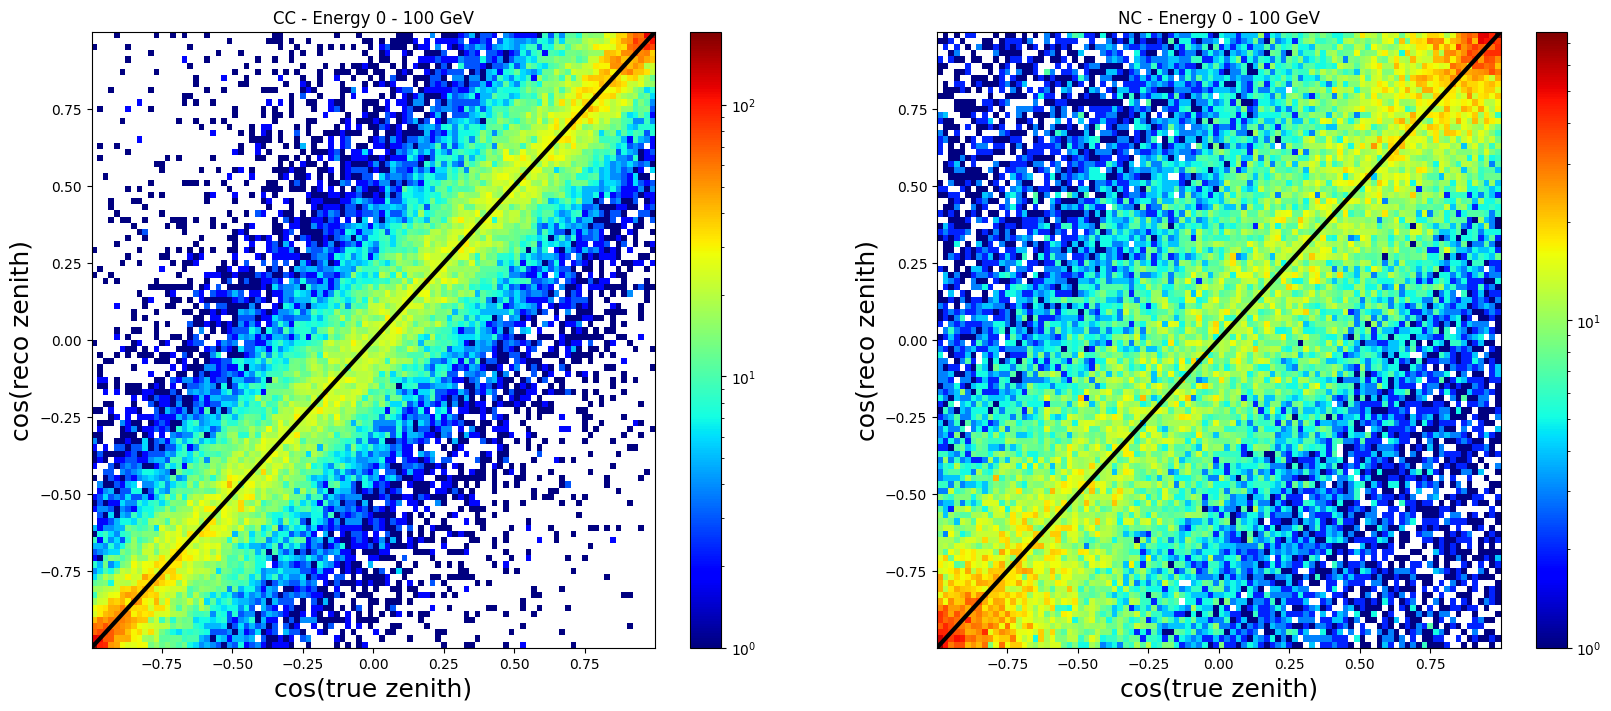

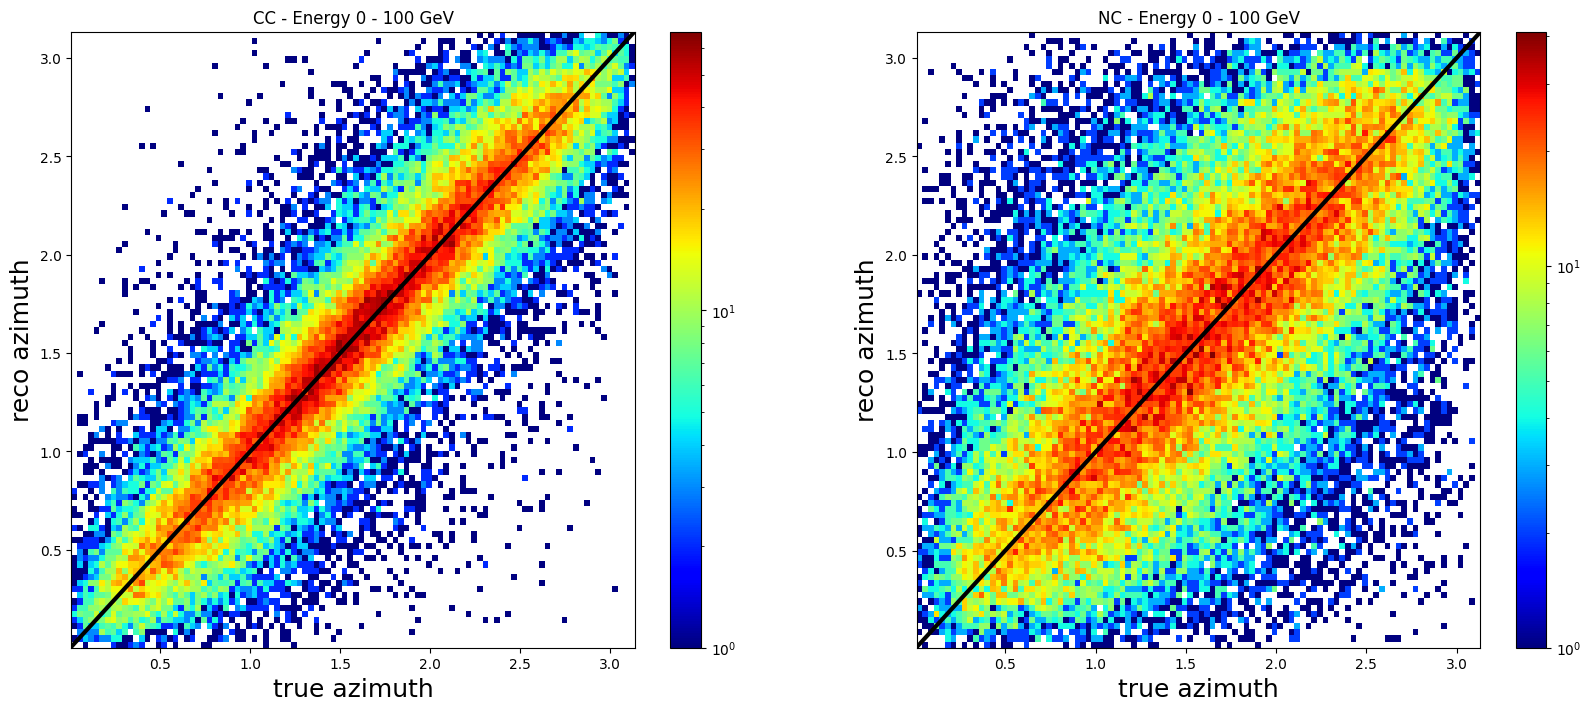

In [14]:
# azimuth and zenith

def calculate_zenith_azimuth(x, y, z):

    r = np.sqrt((x)**2 + (y)**2 + (z)**2)
    theta = np.arccos(z/r)
    phi = np.arctan2(y, x)

    return theta, phi
    
    #az = np.nan_to_num(np.arctan2(y, x))
                            
    #if az < 0:
        #az = az + 2*np.pi

true_zenithCC, true_azimuthCC = filtered_dataCC['Zenith']['value'], filtered_dataCC['Azimuth']['value']
reco_zenithCC, reco_azimuthCC = calculate_zenith_azimuth(filtered_dataCC['RecoDirX']['value'], filtered_dataCC['RecoDirY']['value'], filtered_dataCC['RecoDirZ']['value'])

true_zenithNC, true_azimuthNC = filtered_dataNC['Zenith']['value'], filtered_dataNC['Azimuth']['value']
reco_zenithNC, reco_azimuthNC = calculate_zenith_azimuth(filtered_dataNC['RecoDirX']['value'], filtered_dataNC['RecoDirY']['value'], filtered_dataNC['RecoDirZ']['value'])

reco_vs_true(np.cos(true_zenithCC), np.cos(reco_zenithCC), 'cos(true zenith)', 'cos(reco zenith)',
            np.cos(true_zenithNC), np.cos(reco_zenithNC), 'cos(true zenith)', 'cos(reco zenith)',)

reco_vs_true(true_zenithCC, reco_zenithCC, 'true azimuth', 'reco azimuth',
            true_zenithNC, reco_zenithNC, 'true azimuth', 'reco azimuth',)

Text(0.5, 1.0, 'Energy 10 - 100')

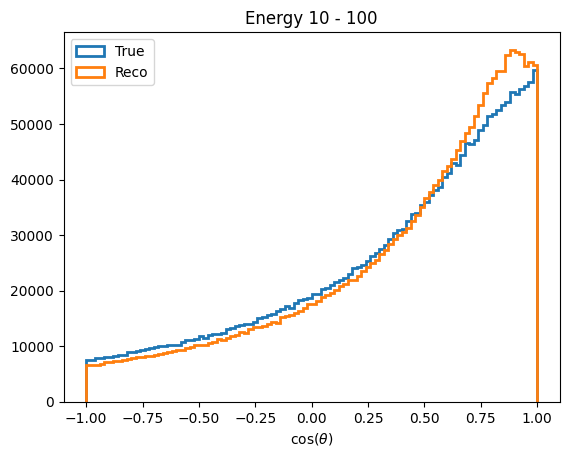

In [12]:
plt.hist(np.cos(filtered_data['OMMapTrue']['angle']), bins=100, histtype='step', lw = 2, label='True')
plt.hist(-np.cos(filtered_data['OMMapReco']['angle_reco']), bins=100, histtype='step', lw = 2, label='Reco')
plt.legend()
plt.xlabel(r'$\cos (\theta)$')
plt.title('Energy {} - {}'.format(emin, emax))

In [ ]:
#### First make event level cuts ######
# cuts on energy
# cuts on inelasticity, only for CC
# cuts on vertex

event_counter = f_nc['EventCounter']['value']
om_counter = f_nc['OMMapTrue']['om_counter']

energy = f_nc['PrimaryEnergy']['value']
inelasticity = f_nc['Inelasticity']['value']

#trueX = f_cc['TrueX']['value']
#trueY = f_cc['TrueY']['value']
#trueZ = f_cc['TrueZ']['value']

emin, emax = 10, 100

imin, imax = 0, 1

energy_boolean = (energy > emin) & (energy <= emax)
#inelasticity_boolean = (inelasticity > imin) & (inelasticity <= imax)

event_boolean = energy_boolean #& inelasticity_boolean

select_event_counter = event_counter[event_boolean]

# Apply the cuts
filtered_data = {}

# Loop through all keys (datasets) and apply the cut
for key in f_nc.keys():
    data = f_nc[key][:]
    if key == 'OMMapReco' or key == 'OMMapTrue':
        om_event_condition = np.where(np.isin(om_counter, select_event_counter))[0]
        filtered_data[key] = data[om_event_condition]
    else:
        filtered_data[key] = data[event_boolean]  # This applies the condition to each dataset